# Notebook 2: Hyperparameter Tuning with MLflow

**Learning Objectives:**
- Run multiple experiments with different parameters
- Compare model performance across runs
- Identify optimal hyperparameters
- Visualize results

**Dataset:** Wine classification

In [ ]:
import mlflow
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

## Step 1: Prepare Data

In [2]:
wine = load_wine()
X, y = wine.data, wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Classes: {wine.target_names}")

Dataset: 178 samples, 13 features
Classes: ['class_0' 'class_1' 'class_2']


## Step 2: Define Parameter Grid

In [5]:
param_grid = [
    {"n_estimators": 50, "max_depth": 3, "min_samples_split": 2},
    {"n_estimators": 100, "max_depth": 3, "min_samples_split": 2},
    {"n_estimators": 50, "max_depth": 5, "min_samples_split": 2},
    {"n_estimators": 100, "max_depth": 5, "min_samples_split": 2},
    {"n_estimators": 50, "max_depth": 10, "min_samples_split": 2},
    {"n_estimators": 100, "max_depth": 10, "min_samples_split": 2},
    {"n_estimators": 200, "max_depth": 5, "min_samples_split": 2},
    {"n_estimators": 200, "max_depth": 10, "min_samples_split": 2},
    {"n_estimators": 100, "max_depth": 5, "min_samples_split": 5},
    {"n_estimators": 100, "max_depth": 5, "min_samples_split": 10},
]

print(f"Testing {len(param_grid)} different configurations")

Testing 10 different configurations


## Step 3: Run Experiments

In [6]:
mlflow.set_experiment("02_Hyperparameter_Tuning")

results = []

for i, params in enumerate(param_grid, 1):
    with mlflow.start_run(run_name=f"Config_{i}"):
        
        params_with_seed = {**params, "random_state": 42}
        
        # Log parameters
        mlflow.log_params(params_with_seed)
        
        model = RandomForestClassifier(**params_with_seed)
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        
        # Log metrics
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("f1_score", f1)
        
        results.append({
            "config": i,
            "n_estimators": params["n_estimators"],
            "max_depth": params["max_depth"],
            "min_samples_split": params["min_samples_split"],
            "accuracy": accuracy,
            "f1_score": f1
        })
        
        print(f"Config {i}: accuracy={accuracy:.4f}, f1={f1:.4f}")

print("\n All experiments completed!")

Config 1: accuracy=1.0000, f1=1.0000
Config 2: accuracy=1.0000, f1=1.0000
Config 3: accuracy=1.0000, f1=1.0000
Config 4: accuracy=1.0000, f1=1.0000
Config 5: accuracy=1.0000, f1=1.0000
Config 6: accuracy=1.0000, f1=1.0000
Config 7: accuracy=1.0000, f1=1.0000
Config 8: accuracy=1.0000, f1=1.0000
Config 9: accuracy=1.0000, f1=1.0000
Config 10: accuracy=1.0000, f1=1.0000

 All experiments completed!


## Step 4: Analyze Results

In [7]:
df_results = pd.DataFrame(results)
df_results = df_results.sort_values('accuracy', ascending=False)

print("\n" + "="*70)
print("TOP 5 CONFIGURATIONS BY ACCURACY")
print("="*70)
print(df_results.head().to_string(index=False))

print("\n" + "="*70)
print("BEST CONFIGURATION")
print("="*70)
best = df_results.iloc[0]
print(f"Config: {int(best['config'])}")
print(f"n_estimators: {int(best['n_estimators'])}")
print(f"max_depth: {int(best['max_depth'])}")
print(f"min_samples_split: {int(best['min_samples_split'])}")
print(f"Accuracy: {best['accuracy']:.4f}")
print(f"F1 Score: {best['f1_score']:.4f}")


TOP 5 CONFIGURATIONS BY ACCURACY
 config  n_estimators  max_depth  min_samples_split  accuracy  f1_score
      1            50          3                  2       1.0       1.0
      2           100          3                  2       1.0       1.0
      3            50          5                  2       1.0       1.0
      4           100          5                  2       1.0       1.0
      5            50         10                  2       1.0       1.0

BEST CONFIGURATION
Config: 1
n_estimators: 50
max_depth: 3
min_samples_split: 2
Accuracy: 1.0000
F1 Score: 1.0000


## Step 5: Visualize Parameter Impact

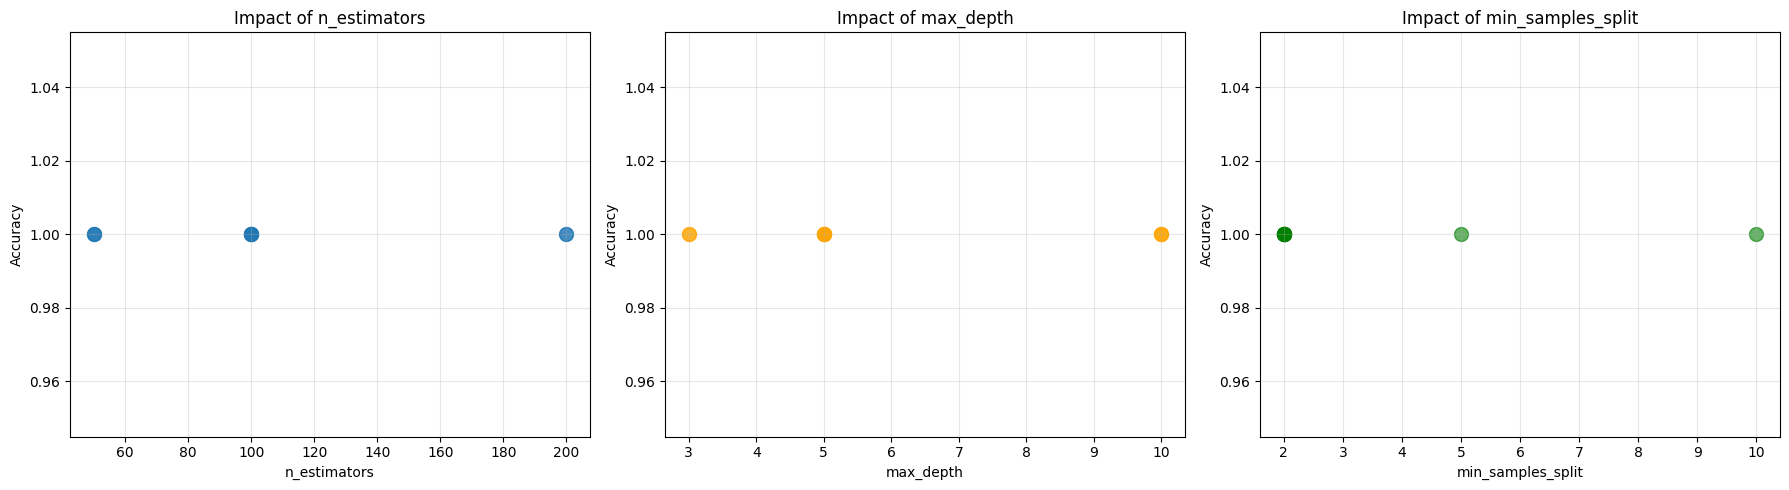


📊 Visualization saved: hyperparameter_analysis.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# n_estimators vs accuracy
axes[0].scatter(df_results['n_estimators'], df_results['accuracy'], alpha=0.6, s=100)
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Impact of n_estimators')
axes[0].grid(True, alpha=0.3)

# max_depth vs accuracy
axes[1].scatter(df_results['max_depth'], df_results['accuracy'], alpha=0.6, s=100, color='orange')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Impact of max_depth')
axes[1].grid(True, alpha=0.3)

# min_samples_split vs accuracy
axes[2].scatter(df_results['min_samples_split'], df_results['accuracy'], alpha=0.6, s=100, color='green')
axes[2].set_xlabel('min_samples_split')
axes[2].set_ylabel('Accuracy')
axes[2].set_title('Impact of min_samples_split')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hyperparameter_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVisualization saved: hyperparameter_analysis.png")

## 🎯 Key Takeaways

1. **Systematic Testing** - Test multiple configurations systematically
2. **MLflow Tracking** - All runs are automatically tracked and comparable
3. **Easy Comparison** - MLflow UI allows side-by-side comparison
4. **Best Model Selection** - Identify optimal hyperparameters based on metrics

## 📝 Exercise

1. Go to MLflow UI and compare all runs
2. Find the run with highest accuracy
3. Check which parameter combination works best
4. Try adding more parameter combinations to the grid